# 🧬 NLP — Named Entity Recognition (NER) with NCBI Disease Corpus

- 📌 **What is NER?**

Named Entity Recognition (NER) is a fundamental task in Natural Language Processing (NLP) that involves identifying and classifying specific spans of text into predefined categories, such as person names, organizations, or locations. In the biomedical domain, NER focuses on domain-specific entities such as diseases, chemicals, and genes.

- ⭐️ **Project Objective**

This notebook presents a reusable Named Entity Recognition (NER) pipeline built using Hugging Face Transformers using the **NCBI Disease Corpus**. It fine-tunes BioBERT for token-level classification to extract disease and chemical entities from PubMed abstracts.

- 💼 **Real-world Applications**

This NER system serves as a foundational layer for downstream biomedical NLP tasks, including:

    🔗 Relation Extraction: Identifying disease–chemical or disease–gene associations
    📚 Literature Mining: Supporting drug discovery and biomedical research
    🏥 Clinical Decision Support: Structuring electronic health records (EHRs)
    🧠 Knowledge Graph Construction: Enabling biomedical semantic search

- 🧠 **Task Setup**

    - **Task Type**: Token-level sequence labeling
    - **Entity Type**: Only one entity class → `Disease`
    - **Dataset**: NCBI Disease Corpus  
      🔸 Created by the National Center for Biotechnology Information  
      🔸 Contains 793 manually annotated PubMed abstracts  
      🔸 Split: 593 (train) / 100 (validation) / 100 (test)  
      🔗 [Paper](https://pubmed.ncbi.nlm.nih.gov/24393765/): *"NCBI Disease Corpus: A resource for disease name recognition and concept normalization"*

## Dataset load

In [57]:
import random
import numpy as np
import torch
from datasets import load_dataset, Dataset, DatasetDict
from transformers import set_seed, AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification, EarlyStoppingCallback

SEED = 44
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

In [2]:
ds = load_dataset("ncbi/ncbi_disease", split="train", trust_remote_code=True)
ds.shape

README.md:   0%|          | 0.00/9.70k [00:00<?, ?B/s]

ncbi_disease.py:   0%|          | 0.00/5.83k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5433 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/924 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/941 [00:00<?, ? examples/s]

(5433, 3)

In [63]:
ds

Dataset({
    features: ['id', 'tokens', 'ner_tags'],
    num_rows: 5433
})

## ner_tags -> tokenized -> labels

In [79]:
ds.features['ner_tags']

Sequence(feature=ClassLabel(names=['O', 'B-Disease', 'I-Disease'], id=None), length=-1, id=None)

In [80]:
label_list = ds.features['ner_tags'].feature.names

In [82]:
labels2id = {l:i for i,l in enumerate(label_list)}
id2labels = {i:l for i,l in enumerate(label_list)}

In [4]:
def preprocess_bio(ds):
    results = []
    for passage in ds['passages']:
        text = passage['text']
        entities = passage.get('entities')
        
        #init character-level labels to match offsets
        char_labels = ['O'] * len(text)
        for ent in entities:
            for start, end in ent['offsets']:
                char_labels[start] = f'B-{ent["type"]}'
                for i in range(start+1, end):
                    char_labels[i] = f'I-{ent["type"]}'

        tokens, offsets=[],[]
        cursor=0
        for token in text.split():
            start = text.find(token, cursor)
            end = start + len(token)
            tokens.append(token)
            offsets.append((start, end))
            cursor = end

        ner_tags=[]
        for start, end in offsets:
            span_labels = set(char_labels[start:end])
            tag = next((t for t in labels if t in span_labels),'O')
            ner_tags.append(labels2id[tag])

        results.append({
            'tokens': tokens,
            'ner_tags':ner_tags
        })

        return results

In [5]:
sample=ds[0]
output = preprocess_bio(sample)
print(output)

[{'tokens': ['Naloxone', 'reverses', 'the', 'antihypertensive', 'effect', 'of', 'clonidine.'], 'ner_tags': [1, 0, 0, 0, 0, 0, 0]}]


**Problems:**
Looks good, but the tokens use the `.split()` will lead to errors!
- For example, the last token `clonidine.` includes `.` , whereas it should be an chemical entity which failed to recognize because the offset cannot match.
- If I manually delete the punctuations will lead to not-match problem with 'offsets' of original text.
- Therefore: no modification on punctuations + the BIO should match with offsets -> Tokenization by 'BioBERT'

### Tokenizer

- `BioBERT` model - better in domain area (bio/chemical)
  - search in huggingface, find one
- why not BERT? It's more common model which may perform poor in specific areas.

In [11]:
from transformers import AutoTokenizer
model_name = "dmis-lab/biobert-base-cased-v1.2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [66]:
def tokenize_and_align_labels(example):
    tokenized_inputs = tokenizer(
        example['tokens'],
        truncation=True,
        is_split_into_words=True
    )
    labels = []
    for i, word_ids in enumerate(tokenized_inputs.word_ids(batch_index=i) for i in range(len(example['tokens']))):    
        label=[]
        prev_word = None
        for word_id in word_ids:
            if word_id is None:
                label.append(-100)
            elif word_id != prev_word:
                label.append(example['ner_tags'][i][word_id])
            else:
                label.append(example['ner_tags'][i][word_id])
            prev_word = word_id
        labels.append(label)
    tokenized_inputs['labels'] = labels
    return tokenized_inputs

In [67]:
train_ds = ds.map(tokenize_and_align_labels, batched=True, remove_columns=['id', 'tokens', 'ner_tags'])

Map:   0%|          | 0/5433 [00:00<?, ? examples/s]

In [69]:
#Check what tokens are
sample = ds[0]
tokenized = tokenizer(
    sample['tokens'],
    truncation=True,
    is_split_into_words=True
)
print("text:",sample['tokens'])
print("---")
print("tokens:",tokenized.tokens())
print("---")
print("tokenized labels:",train_ds[0]['labels'])

text: ['Identification', 'of', 'APC2', ',', 'a', 'homologue', 'of', 'the', 'adenomatous', 'polyposis', 'coli', 'tumour', 'suppressor', '.']
---
tokens: ['[CLS]', 'identification', 'of', 'a', '##p', '##c', '##2', ',', 'a', 'ho', '##mo', '##logue', 'of', 'the', 'ad', '##eno', '##mat', '##ous', 'p', '##oly', '##po', '##sis', 'co', '##li', 't', '##umour', 'suppress', '##or', '.', '[SEP]']
---
tokenized labels: [-100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, -100]


## Train/Valid dataset

In [70]:
t_ds = load_dataset("ncbi/ncbi_disease", split="test", trust_remote_code=True)
test_ds = t_ds.map(tokenize_and_align_labels, batched=True, remove_columns=['id', 'tokens', 'ner_tags'])
v_ds = load_dataset("ncbi/ncbi_disease", split="validation", trust_remote_code=True)
valid_ds = v_ds.map(tokenize_and_align_labels, batched=True, remove_columns=['id', 'tokens', 'ner_tags'])

Map:   0%|          | 0/941 [00:00<?, ? examples/s]

Map:   0%|          | 0/924 [00:00<?, ? examples/s]

## Model training

In [83]:
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    label2id = labels2id,
    id2label = id2labels
)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Data collator
`DataCollatorForTokenClassification`: used in `Trainer` parameter `data_collator=data_collator`, a key tool to manage `padding`, ensure the encoded labels matching with the inputs avoiding errors in specific tasks, such as NER, word-class sentiment analysis, POS tagging, etc.

In [84]:
data_collator = DataCollatorForTokenClassification(tokenizer)

## Metrics
`seqeval` package is designed for NER task's token-level classification_report, f1_score...

In [85]:
import numpy as np
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report

In [86]:
def compute_metrics(outputs):
    predictions, labels = outputs
    preds = np.argmax(predictions, axis=2)
    true_labels,true_preds = [],[]
    for pred, label in zip(preds, labels):
        tmp_preds, tmp_labels=[],[]
        for p_id, l_id, in zip(pred, label):
            if l_id != -100:
                tmp_preds.append(id2labels[p_id])
                tmp_labels.append(id2labels[l_id])
            true_labels.append(tmp_labels)
            true_preds.append(tmp_preds)
                    
    return {
        "precision": precision_score(true_labels, true_preds),
        "recall": recall_score(true_labels, true_preds),
        "f1_score":f1_score(true_labels, true_preds),
        "classification_report": classification_report(true_labels, true_preds)
    }

## Training

In [87]:
train_args = TrainingArguments(output_dir='./009_1_ner_outputs',
                              eval_strategy='epoch',
                              save_strategy='epoch',
                               logging_strategy='epoch',
                               logging_dir='./009_1_ner_logs',
                               learning_rate=2e-5,
                               warmup_ratio=0.1,
                               fp16=False, 
                               bf16=False,
                               per_device_train_batch_size=8,
                               per_device_eval_batch_size=8,
                               num_train_epochs=5,
                               weight_decay=0.01,
                               load_best_model_at_end=True,
                               metric_for_best_model="f1_score",
                               save_total_limit=2,
                               report_to='tensorboard'
                              )

### callbacks

In [88]:
cbs = EarlyStoppingCallback(early_stopping_patience=2)

In [89]:
trainer = Trainer(model, 
                  args=train_args, 
                  train_dataset=train_ds,
                  eval_dataset=valid_ds,
                  data_collator=data_collator,
                  compute_metrics=compute_metrics,
                  callbacks=[cbs]
                 )

In [90]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1 Score,Classification Report
1,0.103900,0.037977,0.820131,0.820131,0.820131,precision recall f1-score support Disease 0.82 0.82 0.82 214912 micro avg 0.82 0.82 0.82 214912 macro avg 0.82 0.82 0.82 214912 weighted avg 0.82 0.82 0.82 214912
2,0.023400,0.034279,0.835593,0.880881,0.857640,precision recall f1-score support Disease 0.84 0.88 0.86 214912 micro avg 0.84 0.88 0.86 214912 macro avg 0.84 0.88 0.86 214912 weighted avg 0.84 0.88 0.86 214912
3,0.010500,0.041834,0.869212,0.827278,0.847727,precision recall f1-score support Disease 0.87 0.83 0.85 214912 micro avg 0.87 0.83 0.85 214912 macro avg 0.87 0.83 0.85 214912 weighted avg 0.87 0.83 0.85 214912
4,0.004600,0.046109,0.863102,0.874926,0.868974,precision recall f1-score support Disease 0.86 0.87 0.87 214912 micro avg 0.86 0.87 0.87 214912 macro avg 0.86 0.87 0.87 214912 weighted avg 0.86 0.87 0.87 214912
5,0.002100,0.049244,0.849252,0.879095,0.863916,precision recall f1-score support Disease 0.85 0.88 0.86 214912 micro avg 0.85 0.88 0.86 214912 macro avg 0.85 0.88 0.86 214912 weighted avg 0.85 0.88 0.86 214912


TrainOutput(global_step=3400, training_loss=0.0289141885322683, metrics={'train_runtime': 572.2548, 'train_samples_per_second': 47.47, 'train_steps_per_second': 5.941, 'total_flos': 890528322249954.0, 'train_loss': 0.0289141885322683, 'epoch': 5.0})

### NCBI (smaller ds) training time longer than BC5CDR?
Though NCBI-Disease has smaller size than BC5CDR, the average tokens length is longer (40-80 tokens each, BC5CDR 20-30 tokens each), the entities are denser, and the tokenizer's splitting granularity is finer, which results in higher computational costs for the Transformer and longer training times, which is a completely normal phenomenon.

### Evaluation

In [91]:
results = trainer.evaluate()

In [92]:
print(results['eval_classification_report'])

              precision    recall  f1-score   support

     Disease       0.86      0.87      0.87    214912

   micro avg       0.86      0.87      0.87    214912
   macro avg       0.86      0.87      0.87    214912
weighted avg       0.86      0.87      0.87    214912



## Predict test_ds

In [93]:
outputs = trainer.predict(test_ds)

In [94]:
print(outputs.metrics['test_classification_report'])

              precision    recall  f1-score   support

     Disease       0.87      0.87      0.87    339300

   micro avg       0.87      0.87      0.87    339300
   macro avg       0.87      0.87      0.87    339300
weighted avg       0.87      0.87      0.87    339300



## Conclusion
This project demonstrates a complete biomedical Named Entity Recognition (NER) pipeline using the NCBI Disease Corpus, targeting the extraction of disease entities from biomedical literature. Leveraging a domain-specific model (BioBERT), we fine-tuned a token classification model using Hugging Face’s Trainer API.

Key takeaways include:
- ✅ Successfully processed word-level token-label alignment using is_split_into_words=True and word_ids()
- ✅ Implemented a universal tokenize_and_align_labels function and compute_metrics using seqeval for entity-level F1 evaluation
- ✅ Achieved strong results on both validation and test sets:
	- F1-score on validation set: 0.87
	- F1-score on test set: 0.87

These results confirm that a fine-tuned BioBERT model can effectively capture domain-specific biomedical entities from scientific abstracts. The engineering design of this notebook (from tokenizer alignment to metric reporting) is reusable for other token classification tasks in medical NLP.

### NCBI comparing with BC5CDR

While both notebooks adopt the same modeling framework (BioBERT + token classification), the NCBI dataset contains only one target entity class, allowing the model to focus its learning and reducing class confusion. This results in a more stable and higher F1-score (0.87 -> 0.87), compared to BC5CDR*, where the model must simultaneously distinguish between both Chemical and Disease entities — increasing the classification complexity.

*BC5CDR's Validation -> Test Set Performance:
- Chemical Entities: F1 = 0.93 -> 0.92
- Disease Entities: F1 = 0.76 -> 0.76

In [95]:
import numpy as np

preds = np.argmax(outputs.predictions, axis=2)

true_labels = [
    [id2labels[l] for (l, m) in zip(label, mask) if m != -100]
    for label, mask in zip(outputs.label_ids, outputs.label_ids)
]
true_predictions = [
    [id2labels[p] for (p, m) in zip(pred, mask) if m != -100]
    for pred, mask in zip(preds, outputs.label_ids)
]

In [98]:
#check test_ds #idx sample
idx = 12  
print("Text:", t_ds[idx]['tokens'])
print("---")
print("Tokens:", tokenizer.convert_ids_to_tokens(test_ds[idx]["input_ids"]))
print("---")
print("Tokenized labels:", test_ds[idx]['labels'])
print("---")
print("True labels:", true_labels[idx])
print("---")
print("Pred labels:", true_predictions[idx])

Text: ['Myotonic', 'dystrophy', 'protein', 'kinase', 'is', 'involved', 'in', 'the', 'modulation', 'of', 'the', 'Ca2', '+', 'homeostasis', 'in', 'skeletal', 'muscle', 'cells', '.']
---
Tokens: ['[CLS]', 'my', '##oto', '##nic', 'd', '##ys', '##tro', '##phy', 'protein', 'kinase', 'is', 'involved', 'in', 'the', 'm', '##od', '##ulation', 'of', 'the', 'ca', '##2', '+', 'home', '##ost', '##asis', 'in', 'skeletal', 'muscle', 'cells', '.', '[SEP]']
---
Tokenized labels: [-100, 1, 1, 1, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -100]
---
True labels: ['B-Disease', 'B-Disease', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
---
Pred labels: ['B-Disease', 'B-Disease', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', '

## Tensorboard
Bash command: `tensorboard --load_fast=False --logdir ./009_ner_logs`

- **Training Convergence Summary**
As shown in the TensorBoard visualization, the model's validation F1-score steadily increased and plateaued around 0.836. Meanwhile, the validation loss exhibited a slight rise in the final epochs, which may suggest minor overfitting. However, since the F1-score did not drop, this checkpoint is considered sufficiently optimal for deployment or further fine-tuning.

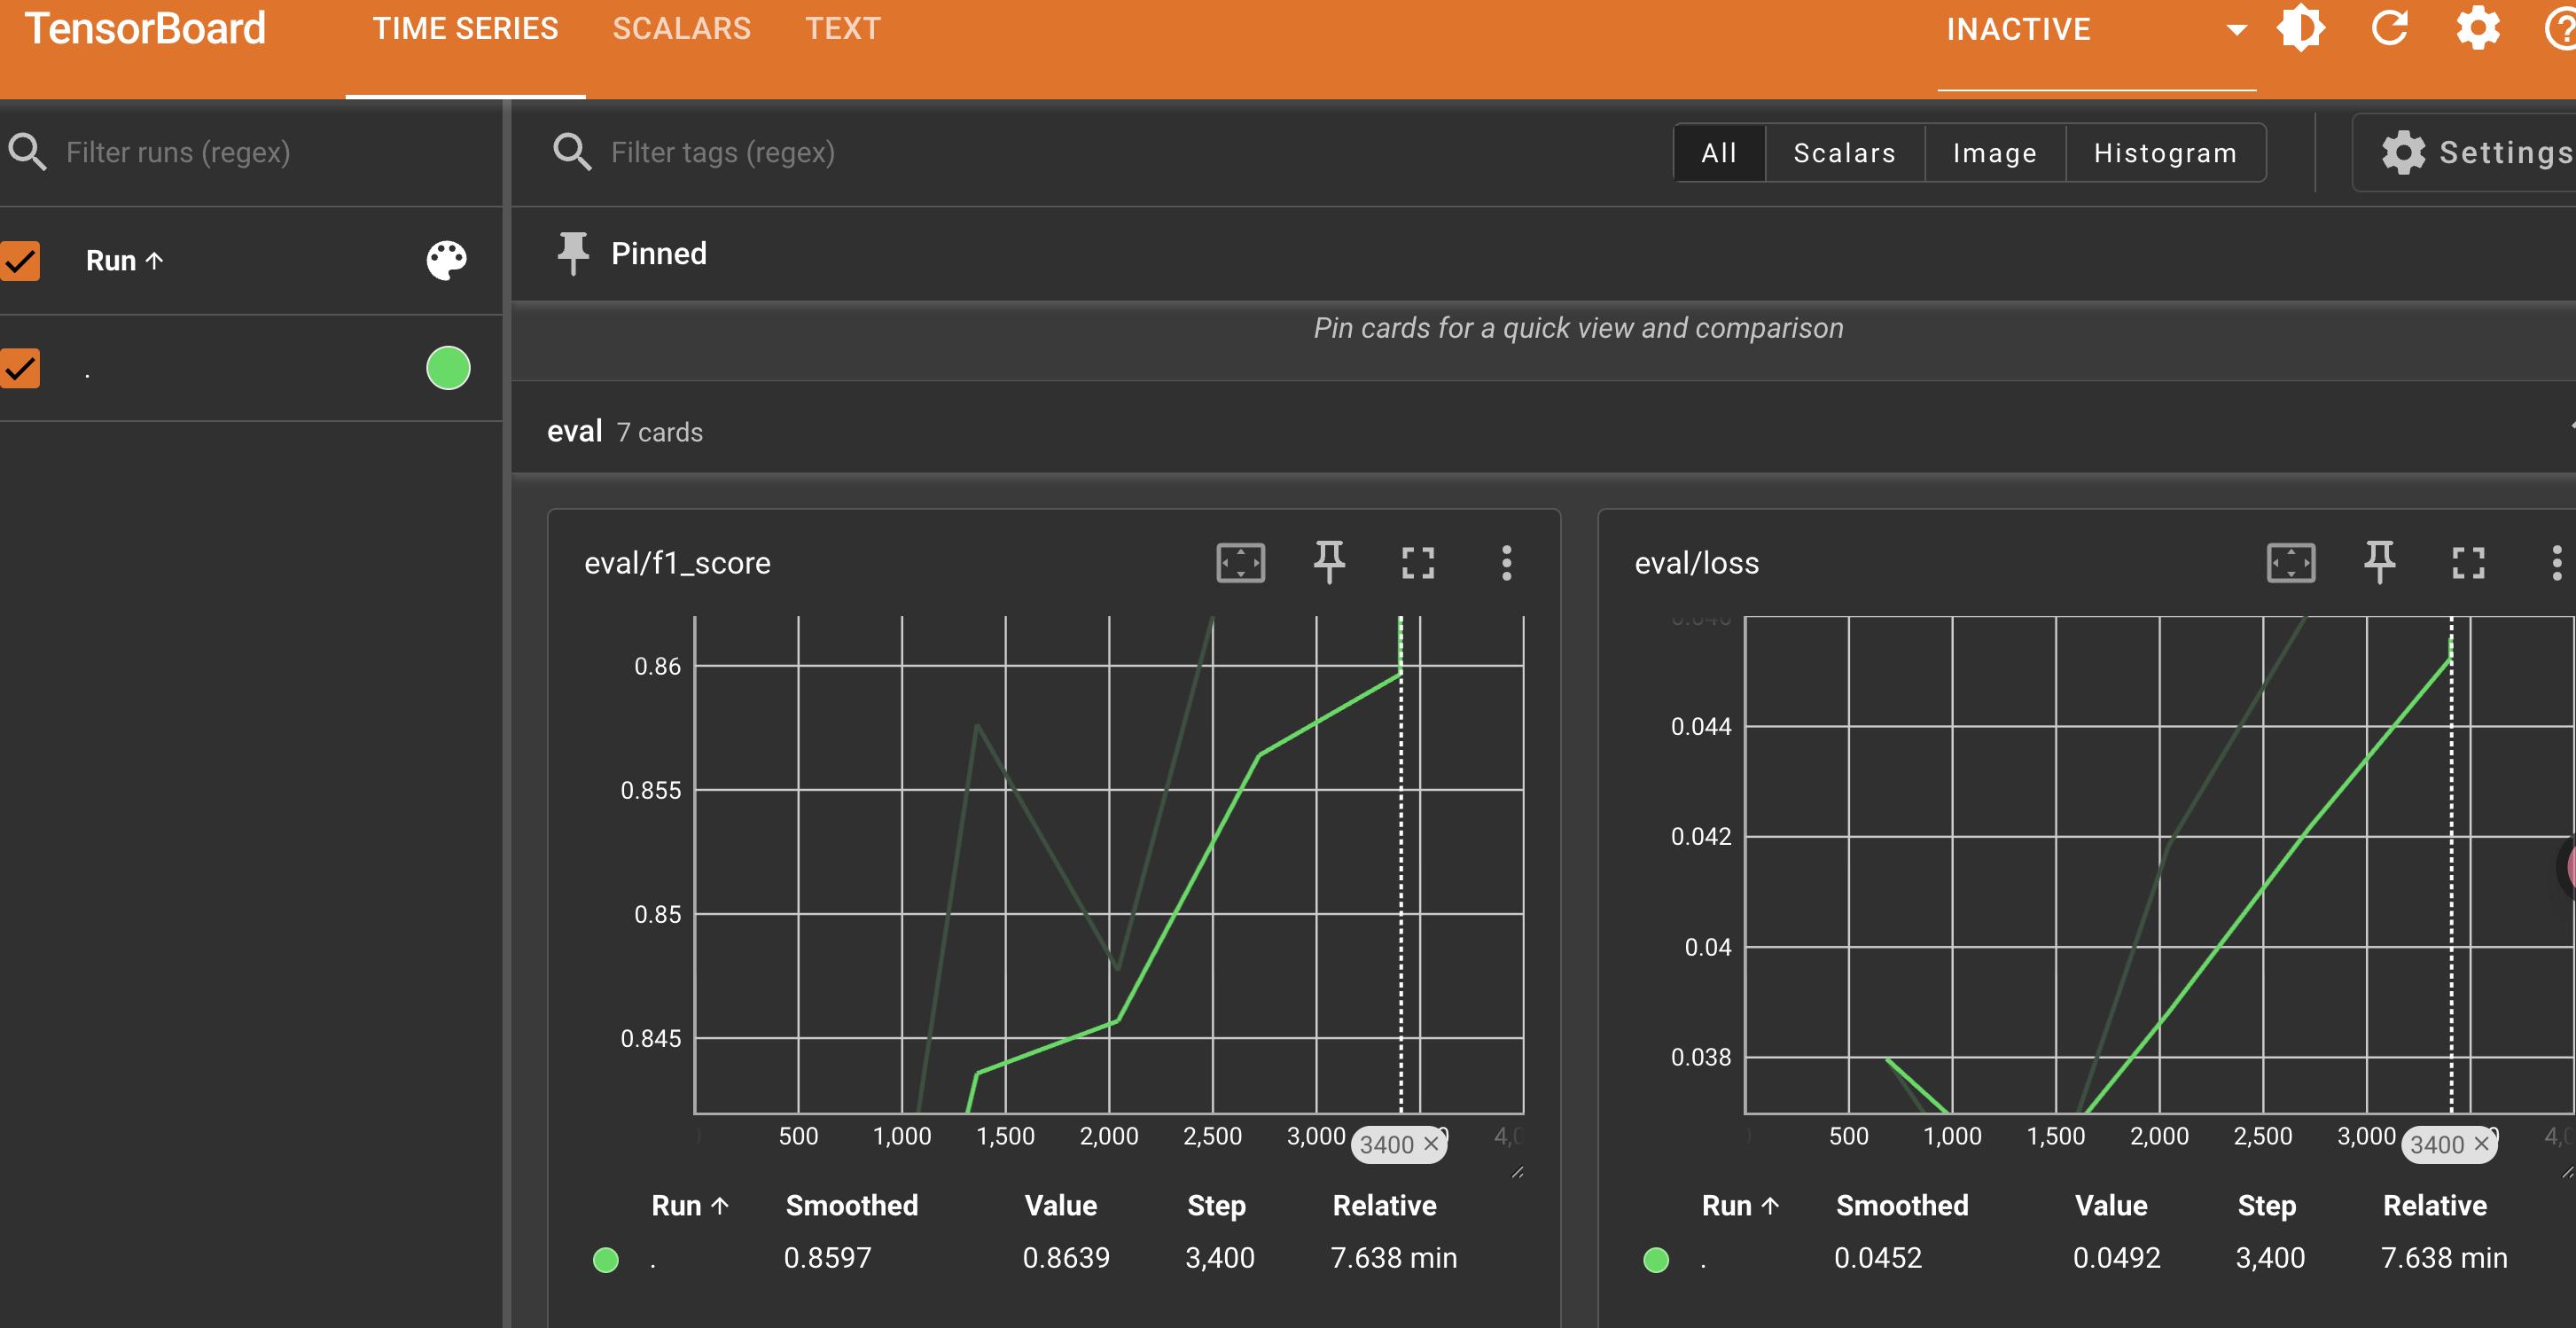

In [100]:
%load_ext tensorboard
%tensorboard --load_fast=false --logdir /Users/applewang/Desktop/Study_Materials_2023_2025/fastai_course/my-practice/009_1_ner_logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 47390), started 0:00:50 ago. (Use '!kill 47390' to kill it.)